In [52]:
# pandas — the main library for working with data tables (DataFrames)
import pandas as pd
# numpy — for numerical operations and handling infinity/NaN values
import numpy as np
# matplotlib — for plotting charts and graphs
import matplotlib.pyplot as plt
# warnings — hide unnecessary output so our notebook stays clean
import warnings
warnings.filterwarnings('ignore')

In [53]:
# pd.read_csv() reads the CSV file and converts it into a DataFrame
# A DataFrame is like an Excel table inside Python
df = pd.read_csv('/content/IPL.csv', on_bad_lines='skip')
# .shape tells us (number of rows, number of columns)
print('Shape:', df.shape)

Shape: (149107, 64)


In [54]:
# .isnull() checks every cell — True if missing, False if not
# .sum() counts how many True values (missing) are in each column
df.isnull().sum()


,0
Unnamed: 0,0
match_id,0
date,0
match_type,0
event_name,0
...,...
batter_balls,28
bowler_wicket,28
batting_partners,31
next_batter,141998


In [55]:
# Keep only rows where innings == 2 (the chasing team's deliveries)
# .copy() creates an independent copy so we don't accidentally modify the original
df = df[df['innings'] == 2].copy()
# dropna(subset=[...]) removes rows where the specified column is missing
# runs_target is NaN in 1st innings rows — we've already removed those,
# but this is a safety check
df = df.dropna(subset=['runs_target'])
# Remove rows where city is 'Unknown' — we can't use unknown cities
# as a feature for the model
df = df[df['city'] != 'Unknown']
# Print how many rows remain after cleaning
print('Rows remaining:', len(df))


Rows remaining: 56202


In [56]:
# Dictionary mapping old names → new names
team_rename = {
'Delhi Daredevils' : 'Delhi Capitals', # renamed in 2019
'Deccan Chargers' : 'Sunrisers Hyderabad', # replaced in 2013
'Kings XI Punjab' : 'Punjab Kings', # renamed in 2021
'Rising Pune Supergiant' : 'Rising Pune Supergiants', # name fix
'Royal Challengers Bangalore' : 'Royal Challengers Bengaluru', # renamed in 2023
}
# Apply the rename to all three team-related columns
# .replace() swaps old values with new values based on the dictionary
for col in ['batting_team', 'bowling_team', 'match_won_by']:
  df[col] = df[col].replace(team_rename)


In [57]:
# List of current active IPL franchises (10 teams)
TEAMS = ['Chennai Super Kings', 'Delhi Capitals', 'Gujarat Titans',
'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians',
'Punjab Kings', 'Rajasthan Royals', 'Royal Challengers Bengaluru',
'Sunrisers Hyderabad']
# .isin(TEAMS) returns True only if the value is in our TEAMS list
# We apply this to BOTH batting and bowling team columns using & (AND)
# This removes defunct teams like Kochi Tuskers, Pune Warriors etc.
df = df[df['batting_team'].isin(TEAMS) & df['bowling_team'].isin(TEAMS)]
# Verify — should show exactly 10 teams
print('Teams:', sorted(df['batting_team'].unique()))

Teams: ['Chennai Super Kings', 'Delhi Capitals', 'Kolkata Knight Riders', 'Mumbai Indians', 'Punjab Kings', 'Rajasthan Royals', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']


In [58]:
# Remove rows where team_balls = 0 (the very first ball of the innings)
# We can't divide by 0 when calculating run rates
# Convert 'team_balls' to numeric, coercing errors to NaN
df['team_balls'] = pd.to_numeric(df['team_balls'], errors='coerce')
# Drop rows where 'team_balls' is NaN after conversion
df = df.dropna(subset=['team_balls'])
df = df[df['team_balls'] > 0]

# Convert 'runs_target' and 'team_runs' to numeric to allow subtraction
df['runs_target'] = pd.to_numeric(df['runs_target'], errors='coerce')
df['team_runs'] = pd.to_numeric(df['team_runs'], errors='coerce')
df = df.dropna(subset=['runs_target', 'team_runs'])

# How many more runs does the batting team need to win?
df['runs_left'] = df['runs_target'] - df['team_runs']
# How many valid balls are remaining? (T20 = 120 balls total)
# team_balls counts only legal deliveries (not wides/no-balls)
df['balls_left'] = 120 - df['team_balls']
# How many wickets does the batting team still have?
df['team_wicket'] = pd.to_numeric(df['team_wicket'], errors='coerce')
df = df.dropna(subset=['team_wicket'])
df['wickets_remaining'] = 10 - df['team_wicket']
# Current Run Rate = runs scored so far per over
# (team_balls / 6) converts balls to overs
df['crr'] = (df['team_runs'] * 6 / df['team_balls']).round(2)
# Required Run Rate = runs still needed per over remaining
df['rrr'] = (df['runs_left'] * 6 / df['balls_left']).round(2)
# Target variable: 1 if the batting team won, 0 if they lost
# This is what the model will learn to predict
df['result'] = (df['batting_team'] == df['match_won_by']).astype(int)

In [59]:
# Select only the columns we need — 9 features + 1 target
FEATURES = ['batting_team', 'bowling_team', 'city',
'runs_left', 'balls_left', 'wickets_remaining',
'runs_target', 'crr', 'rrr', 'result']
# Create a clean copy with only these columns
final_df = df[FEATURES].copy()
# Replace infinity values (happen when dividing by zero) with NaN
# Then drop any rows that have NaN in any column
# np.inf = positive infinity, -np.inf = negative infinity
final_df = final_df.replace([np.inf, -np.inf], np.nan).dropna()
# Confirm the final shape of our clean dataset
print('Final shape:', final_df.shape)
final_df.head()


Final shape: (47278, 10)


,batting_team,bowling_team,city,runs_left,balls_left,wickets_remaining,runs_target,crr,rrr,result
8203,Delhi Capitals,Mumbai Indians,Mumbai,163.0,119.0,10.0,163.0,0.0,8.22,0
8204,Delhi Capitals,Mumbai Indians,Mumbai,162.0,118.0,10.0,163.0,3.0,8.24,0
8205,Delhi Capitals,Mumbai Indians,Mumbai,161.0,117.0,10.0,163.0,4.0,8.26,0
8206,Delhi Capitals,Mumbai Indians,Mumbai,161.0,116.0,10.0,163.0,3.0,8.33,0
8207,Delhi Capitals,Mumbai Indians,Mumbai,161.0,115.0,10.0,163.0,2.4,8.40,0


In [60]:
# groupby('batting_team') — splits the DataFrame into groups, one per team
# ['result'] — we look at the result column for each group
# .mean() — average of result (since result is 0 or 1, mean = win percentage)
# * 100 — convert to percentage
# .round(1) — round to 1 decimal place
# .sort_values(ascending=False) — show highest win % at the top
win_pct = (final_df.groupby('batting_team')['result']
.mean().sort_values(ascending=False) * 100).round(1)
print(win_pct)


batting_team
Chennai Super Kings            69.5
Kolkata Knight Riders          59.7
Mumbai Indians                 56.3
Rajasthan Royals               54.0
Royal Challengers Bengaluru    52.9
Delhi Capitals                 51.4
Punjab Kings                   50.4
Sunrisers Hyderabad            33.6
Name: result, dtype: float64


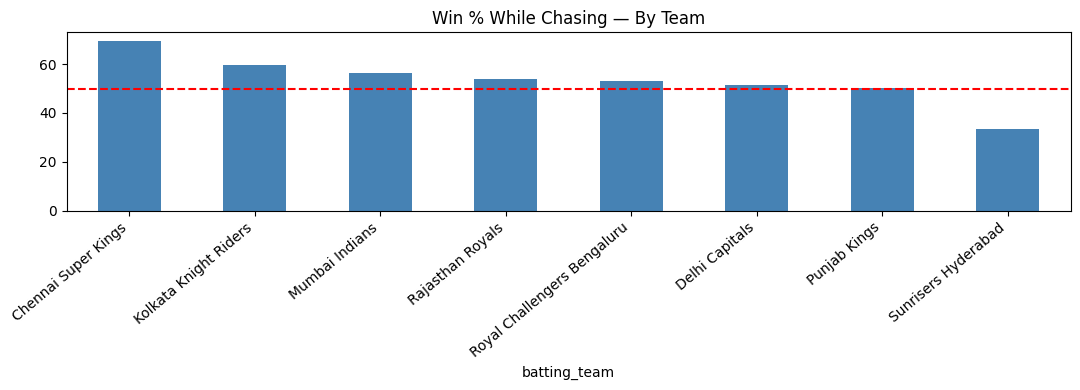

In [61]:
# .plot(kind='bar') creates a bar chart from the Series
win_pct.plot(kind='bar', figsize=(11, 4), color='steelblue')
# Add a title to the chart
plt.title('Win % While Chasing — By Team')
# Draw a horizontal red dashed line at 50% for reference
plt.axhline(50, color='red', linestyle='--', label='50%')
# Rotate x-axis labels so team names don't overlap
plt.xticks(rotation=40, ha='right')
# Automatically adjust spacing so nothing gets cut off
plt.tight_layout()
# Display the chart
plt.show()


In [62]:
# .to_csv() saves the DataFrame as a CSV file
# index=False means don't write the row numbers (0,1,2...) as a column
final_df.to_csv('IPL_processed_dataset.csv', index=False)
print('Saved processed_dataset.csv')
print('Rows:', len(final_df))
print()


Saved processed_dataset.csv
Rows: 47278



In [63]:
import pickle
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [64]:
df = pd.read_csv('/content/IPL_processed_dataset.csv')
print('Shape:', df.shape)
df.head()

Shape: (47278, 10)


,batting_team,bowling_team,city,runs_left,balls_left,wickets_remaining,runs_target,crr,rrr,result
0,Delhi Capitals,Mumbai Indians,Mumbai,163.0,119.0,10.0,163.0,0.0,8.22,0
1,Delhi Capitals,Mumbai Indians,Mumbai,162.0,118.0,10.0,163.0,3.0,8.24,0
2,Delhi Capitals,Mumbai Indians,Mumbai,161.0,117.0,10.0,163.0,4.0,8.26,0
3,Delhi Capitals,Mumbai Indians,Mumbai,161.0,116.0,10.0,163.0,3.0,8.33,0
4,Delhi Capitals,Mumbai Indians,Mumbai,161.0,115.0,10.0,163.0,2.4,8.40,0


In [65]:
X = df.drop('result', axis=1)
y = df['result']
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.25, random_state=42)
print('Training rows:', len(X_train))
print('Testing rows: ', len(X_test))


Training rows: 35458
Testing rows:  11820


In [66]:
CATEGORICAL = ['batting_team', 'bowling_team', 'city']
NUMERIC = ['runs_left', 'balls_left', 'wickets_remaining',
'runs_target', 'crr', 'rrr']
preprocessor = ColumnTransformer([
('cat', OneHotEncoder(
sparse_output=False,
drop='first',
handle_unknown='ignore'
), CATEGORICAL),
('num', StandardScaler(), NUMERIC)
])
pipe = Pipeline([
('step1', preprocessor),
('step2', LogisticRegression(solver='liblinear', max_iter=1000))
])
print('Pipeline built!')


Pipeline built!


In [67]:
pipe.fit(X_train, y_train)
print('Model trained!')

Model trained!


In [68]:
y_pred = pipe.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc * 100:.2f}%')

Accuracy: 83.40%


In [69]:
pickle.dump(pipe, open('pipe.pkl', 'wb'))
print('Saved: pipe.pkl')
loaded = pickle.load(open('pipe.pkl', 'rb'))
verify_acc = accuracy_score(y_test, loaded.predict(X_test))
print(f'Reload accuracy: {verify_acc * 100:.2f}% ✓')

Saved: pipe.pkl
Reload accuracy: 83.40% ✓


In [70]:
import ipywidgets as widgets
from IPython.display import display
ALL_CITIES = sorted(df['city'].unique().tolist())

In [71]:
TEAMS = sorted(df['batting_team'].unique().tolist())
batting_team_widget = widgets.Dropdown(
options=TEAMS,
description='Batting Team:',
disabled=False,
continuous_update=False
)
bowling_team_widget = widgets.Dropdown(
options=TEAMS,
description='Bowling Team:',
disabled=False,
continuous_update=False
)
city_widget = widgets.Dropdown(
options=ALL_CITIES,
description='City:',
disabled=False,
continuous_update=False
)
runs_left_widget = widgets.IntText(
value=50,
description='Runs Left:',
disabled=False
)
balls_left_widget = widgets.IntText(
value=30,
description='Balls Left:',
disabled=False
)
wickets_remaining_widget = widgets.IntText(
value=7,
description='Wickets Remaining:',
disabled=False
)
runs_target_widget = widgets.IntText(
value=180,
description='Target Score:',
disabled=False
)
crr_widget = widgets.FloatText(
value=9.0,
description='Current RR:',
disabled=False
)
rrr_widget = widgets.FloatText(
value=10.0,
description='Required RR:',
disabled=False
)
predict_button = widgets.Button(description='Predict Win Probability')
output_widget = widgets.Output()
display(
batting_team_widget, bowling_team_widget, city_widget,
runs_left_widget, balls_left_widget, wickets_remaining_widget,
runs_target_widget, crr_widget, rrr_widget,
predict_button, output_widget
)

Dropdown(description='Batting Team:', options=('Chennai Super Kings', 'Delhi Capitals', 'Kolkata Knight Riders…

Dropdown(description='Bowling Team:', options=('Chennai Super Kings', 'Delhi Capitals', 'Kolkata Knight Riders…

Dropdown(description='City:', options=('Ahmedabad', 'Bangalore', 'Bloemfontein', 'Centurion', 'Chandigarh', 'C…

IntText(value=50, description='Runs Left:')

IntText(value=30, description='Balls Left:')

...

IntText(value=180, description='Target Score:')

FloatText(value=9.0, description='Current RR:')

FloatText(value=10.0, description='Required RR:')

Button(description='Predict Win Probability', style=ButtonStyle())

Output()

In [75]:
def on_predict_button_clicked(b):
    with output_widget:
        output_widget.clear_output()
        try:
            input_data = pd.DataFrame({
                'batting_team': [batting_team_widget.value],
                'bowling_team': [bowling_team_widget.value],
                'city': [city_widget.value],
                'runs_left': [runs_left_widget.value],
                'balls_left': [balls_left_widget.value],
                'wickets_remaining': [wickets_remaining_widget.value],
                'runs_target': [runs_target_widget.value],
                'crr': [crr_widget.value],
                'rrr': [rrr_widget.value]
            })
            prediction = pipe.predict_proba(input_data)
            win_prob_batting_team = round(prediction[0][1] * 100, 2)
            win_prob_bowling_team = round(prediction[0][0] * 100, 2)
            print(f'{batting_team_widget.value} Win Probability: {win_prob_batting_team}%')
            print(f'{bowling_team_widget.value} Win Probability: {win_prob_bowling_team}%')
        except Exception as e:
            print(f"An error occurred: {e}")
predict_button.on_click(on_predict_button_clicked)